# Model 5: MobileNetV2 Pre-trained Transfer Learning

**Malaria Diagnosis from Microscopic Cell Images** — Parasitized vs. Uninfected.

MobileNetV2 is a lightweight, depthwise-separable convolutional architecture pre-trained on the
ImageNet dataset. Its inverted-residual / linear-bottleneck design makes it dramatically smaller
and faster than VGG16 or ResNet50 while remaining competitive in accuracy — an attractive
property for malaria screening on low-resource edge hardware. By freezing the feature-extraction
base and attaching a small classification head, we transfer ImageNet's visual pattern-recognition
to identify malaria parasites in blood smears.

Seven individual experiments are systematically conducted by altering the **learning rate,
optimizer, classifier-head capacity, dropout regularization, data augmentation, and fine-tuning
depth**. Each experiment is evaluated with accuracy, precision, recall and F1-score, plus learning
curves, a confusion matrix and a ROC/AUC curve.

> **Preprocessing note:** Unlike the team's VGG16/ResNet50 notebooks (which use
> `Rescaling(1/255)`), this notebook uses MobileNetV2's **official `preprocess_input`**, which
> scales pixels to `[-1, 1]` — the range the pretrained weights expect. This is the technically
> correct preprocessing for MobileNetV2 and is discussed in the report.


## 1. Environment Setup

In [2]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU device active:", tf.test.gpu_device_name())

TensorFlow version: 2.20.0
GPU device active: /device:GPU:0


## 2. Import Libraries

In [3]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("All libraries imported successfully.")

All libraries imported successfully.


## 3. Data Loading

We use the public NIH malaria dataset (~27,558 cell images, evenly split between *Parasitized*
and *Uninfected*). The pipeline matches the rest of the group's notebooks: an 80/20 train/val
split, `128x128` images, batch size 32, fixed seed, and a cached/prefetched `tf.data` pipeline.

> **Note:** `val_ds` is **not shuffled** (only `train_ds` is). This matters for evaluation: it
> means iterating the validation set twice yields the same order, so predictions and labels stay
> aligned in the optimized `evaluate_model` helper below.

In [4]:
if not os.path.exists('cell_images'):
    print("Downloading dataset...")
    !wget -q https://data.lhncbc.nlm.nih.gov/public/Malaria/cell_images.zip
    !unzip -q cell_images.zip
    print("Done.")
else:
    print("Dataset already exists, skipping download.")

parasitized = len(os.listdir('cell_images/Parasitized'))
uninfected = len(os.listdir('cell_images/Uninfected'))
print(f"Parasitized images: {parasitized}")
print(f"Uninfected images:  {uninfected}")

Dataset already exists, skipping download.
Parasitized images: 13780
Uninfected images:  13780


In [5]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    "cell_images",
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "cell_images",
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

CLASS_NAMES = train_ds.class_names
print("Classes:", CLASS_NAMES)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 27558 files belonging to 2 classes.
Using 22047 files for training.
Found 27558 files belonging to 2 classes.
Using 5511 files for validation.
Classes: ['Parasitized', 'Uninfected']


## 4. Evaluation Helper Functions

Shared helpers so every model is evaluated identically: `evaluate_model` (metrics + classification
report), `plot_learning_curves`, `plot_confusion_matrix`, and `plot_roc_curve`.

> **Optimization:** `evaluate_model` calls `model.predict(dataset)` **once** over the whole
> validation set instead of once per batch inside a Python loop. Keras batches internally, so this
> is far faster and avoids the *"predict is being called inside a loop"* slowdown. Labels are
> gathered in the same (unshuffled) order, so they stay aligned with the predictions.

In [6]:
def evaluate_model(model, dataset):
    """Run inference once over a dataset; return true labels, predicted labels, and raw scores."""
    y_scores = model.predict(dataset, verbose=0).flatten()
    y_true = np.concatenate([labels.numpy() for _, labels in dataset])
    y_pred = (y_scores > 0.5).astype(int)
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))
    return y_true, y_pred, y_scores


def plot_learning_curves(history, title="Learning Curves"):
    """Plot training vs validation accuracy and loss. Accepts a Keras History object or a dict."""
    h = history.history if hasattr(history, "history") else history
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(h['accuracy'], label='Train Accuracy')
    axes[0].plot(h['val_accuracy'], label='Val Accuracy')
    axes[0].set_title(f'{title} — Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()

    axes[1].plot(h['loss'], label='Train Loss')
    axes[1].plot(h['val_loss'], label='Val Loss')
    axes[1].set_title(f'{title} — Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()

    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix"):
    """Plot a labelled confusion matrix."""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 5))
    plt.imshow(cm, cmap='Blues')
    plt.title(title)
    plt.colorbar()
    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j], ha='center', va='center', fontsize=14, color='black')
    plt.xticks([0, 1], CLASS_NAMES)
    plt.yticks([0, 1], CLASS_NAMES)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()


def plot_roc_curve(y_true, y_scores, title="ROC Curve"):
    """Plot ROC curve and print AUC score."""
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(5, 5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], '--', color='gray')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()
    print(f"AUC: {roc_auc:.4f}")
    return roc_auc


print("Helper functions defined successfully.")

Helper functions defined successfully.


## 5. Core Reusable Model Builder Function

A single function builds every experiment. Parameters control the classifier head
(`dense_units`, `dropout_rate`), the optimizer (`optimizer_name`, `learning_rate`), optional
on-the-fly **data augmentation**, and the number of top base layers to **fine-tune**
(`fine_tune_layers`).

Two MobileNetV2-specific details matter:

1. **`preprocess_input`** is applied inside the model so inputs are scaled to `[-1, 1]`.
2. The base is always called with **`training=False`** so its **BatchNormalization** layers use
   their pretrained running statistics. This avoids the well-known accuracy collapse that occurs
   when frozen BN stats get updated during fine-tuning. The augmentation layers are built *inside*
   the model (not as a shared global) so the function is safe to call repeatedly after
   `clear_session()`.

In [7]:
def build_mobilenetv2_model(dense_units=256, dropout_rate=0.5, learning_rate=1e-3,
                            optimizer_name="adam", fine_tune_layers=0, use_augmentation=False):
    """
    Builds a MobileNetV2 transfer-learning model for binary malaria classification.
    Input is 128x128x3 to stay consistent with the group's dataset standard.
    """
    base_model = MobileNetV2(
        weights='imagenet',
        include_top=False,
        input_shape=(128, 128, 3)
    )

    if fine_tune_layers == 0:
        base_model.trainable = False
    else:
        base_model.trainable = True
        # Freeze all but the last `fine_tune_layers` layers.
        for layer in base_model.layers[:-fine_tune_layers]:
            layer.trainable = False
        # Keep every BatchNorm layer frozen to preserve pretrained statistics.
        for layer in base_model.layers:
            if isinstance(layer, layers.BatchNormalization):
                layer.trainable = False

    inputs = tf.keras.Input(shape=(128, 128, 3))
    x = inputs
    if use_augmentation:
        x = layers.RandomFlip("horizontal_and_vertical")(x)
        x = layers.RandomRotation(0.2)(x)
        x = layers.RandomZoom(0.2)(x)
    x = preprocess_input(x)                       # scale to [-1, 1] for MobileNetV2
    x = base_model(x, training=False)             # BN layers in inference mode
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(dense_units, activation='relu')(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = tf.keras.Model(inputs, outputs)

    if optimizer_name == "adam":
        opt = Adam(learning_rate=learning_rate)
    else:
        opt = SGD(learning_rate=learning_rate, momentum=0.9)

    model.compile(
        optimizer=opt,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model


print("Model builder defined successfully.")

Model builder defined successfully.


## 6. The 7 Experiment Configurations

Each experiment changes exactly one design dimension relative to the baseline so its effect can be
isolated and interpreted. All experiments train for 10 epochs.

| ID | What changes vs. baseline |
|----|---------------------------|
| **E1_MNV2_Baseline** | Frozen base, dense=256, dropout=0.5, lr=1e-3, Adam |
| **E2_MNV2_Lower_LR** | Learning rate 1e-4 |
| **E3_MNV2_SGD_Opt** | Optimizer SGD(momentum=0.9), lr=1e-3 |
| **E4_MNV2_Dense64** | Smaller classifier head (dense=64) |
| **E5_MNV2_Dropout0.7** | Stronger regularization (dropout=0.7) |
| **E6_MNV2_Augment** | On-the-fly data augmentation, frozen base |
| **E7_MNV2_FineTune** | Unfreeze last 20 base layers, lr=1e-5 |

In [8]:
EXPERIMENTS = {
    "E1_MNV2_Baseline":   dict(dense_units=256, dropout_rate=0.5, learning_rate=1e-3, optimizer_name="adam"),
    "E2_MNV2_Lower_LR":   dict(dense_units=256, dropout_rate=0.5, learning_rate=1e-4, optimizer_name="adam"),
    "E3_MNV2_SGD_Opt":    dict(dense_units=256, dropout_rate=0.5, learning_rate=1e-3, optimizer_name="sgd"),
    "E4_MNV2_Dense64":    dict(dense_units=64,  dropout_rate=0.5, learning_rate=1e-3, optimizer_name="adam"),
    "E5_MNV2_Dropout0.7": dict(dense_units=256, dropout_rate=0.7, learning_rate=1e-3, optimizer_name="adam"),
    "E6_MNV2_Augment":    dict(dense_units=256, dropout_rate=0.5, learning_rate=1e-3, optimizer_name="adam", use_augmentation=True),
    "E7_MNV2_FineTune":   dict(dense_units=256, dropout_rate=0.5, learning_rate=1e-5, optimizer_name="adam", fine_tune_layers=20),
}

print(f"{len(EXPERIMENTS)} experiments configured.")

7 experiments configured.


## 7. Train, Evaluate & Visualize — Single Pass

This one loop trains each experiment, evaluates it (a single `predict` pass), draws its three
plots, **then frees the model from memory before the next run**. Processing one model at a time
keeps only a single MobileNetV2 on the GPU at once, which avoids out-of-memory crashes on a Colab
T4. We collect the metrics row, the prediction arrays, and the history `dict` for each experiment
so the consolidated table (Section 8) and any later re-plotting work without keeping the models
alive.

Read each experiment's three plots together: the learning curves reveal
overfitting/underfitting, the confusion matrix shows which class is misclassified (clinically,
false negatives on *Parasitized* cells are the most dangerous), and the ROC/AUC summarizes the
sensitivity–specificity trade-off.


[Training] E1_MNV2_Baseline  —  {'dense_units': 256, 'dropout_rate': 0.5, 'learning_rate': 0.001, 'optimizer_name': 'adam'}
Epoch 1/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 87s 62ms/step - accuracy: 0.8997 - loss: 0.2476 - val_accuracy: 0.9285 - val_loss: 0.1807
Epoch 2/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.9224 - loss: 0.2027 - val_accuracy: 0.9349 - val_loss: 0.1711
Epoch 3/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.9296 - loss: 0.1857 - val_accuracy: 0.9394 - val_loss: 0.1631
Epoch 4/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.9304 - loss: 0.1812 - val_accuracy: 0.9383 - val_loss: 0.1633
Epoch 5/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.9345 - loss: 0.1747 - val_accuracy: 0.9370 - val_loss: 0.1620
Epoch 6/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.9350 - loss: 0.1700 - val_accuracy: 0.9403 - val_loss: 0.1596
Epoch 7/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.9369 - loss: 0.1680 - val_accur

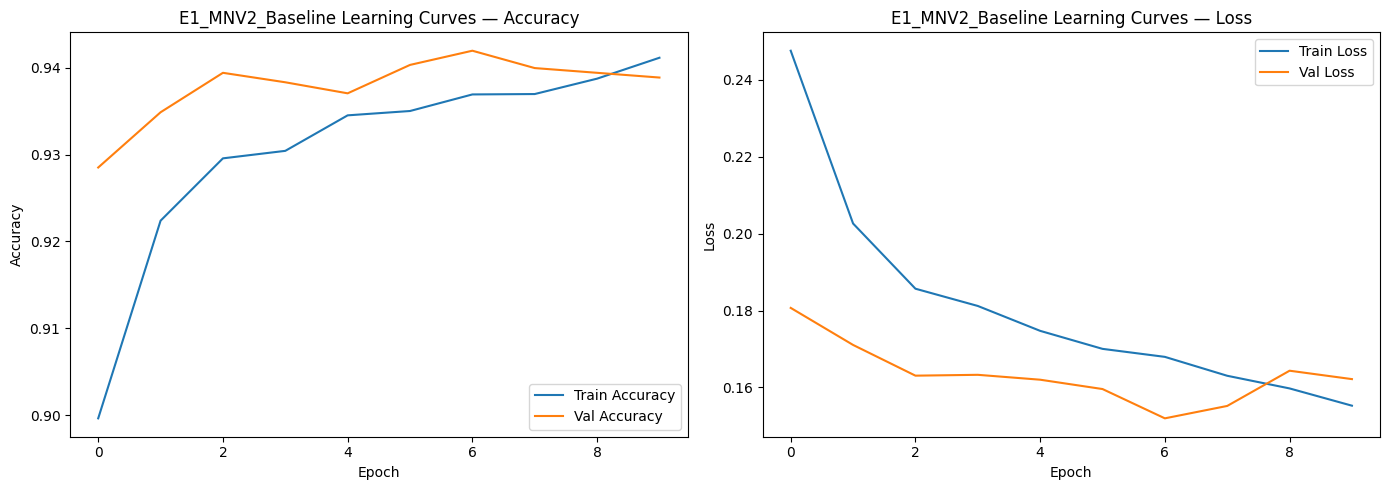

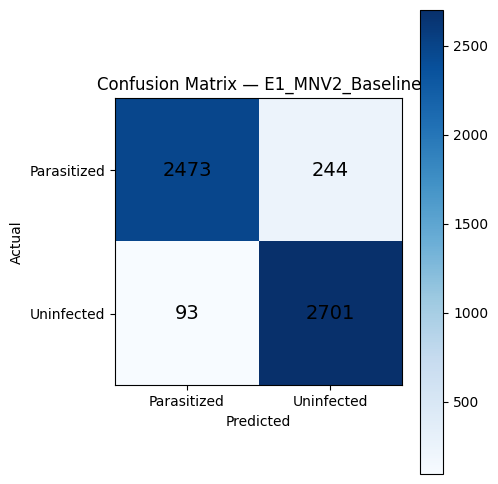

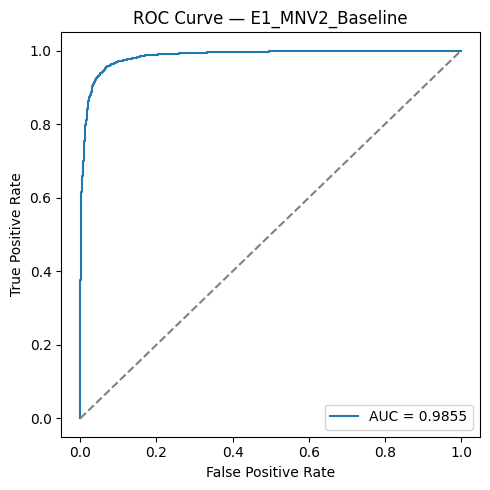

AUC: 0.9855

[Training] E2_MNV2_Lower_LR  —  {'dense_units': 256, 'dropout_rate': 0.5, 'learning_rate': 0.0001, 'optimizer_name': 'adam'}
Epoch 1/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 33s 33ms/step - accuracy: 0.8677 - loss: 0.3041 - val_accuracy: 0.9236 - val_loss: 0.2092
Epoch 2/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.9179 - loss: 0.2147 - val_accuracy: 0.9332 - val_loss: 0.1831
Epoch 3/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.9243 - loss: 0.1957 - val_accuracy: 0.9358 - val_loss: 0.1742
Epoch 4/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.9324 - loss: 0.1811 - val_accuracy: 0.9372 - val_loss: 0.1670
Epoch 5/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.9341 - loss: 0.1754 - val_accuracy: 0.9349 - val_loss: 0.1640
Epoch 6/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.9383 - loss: 0.1675 - val_accuracy: 0.9378 - val_loss: 0.1601
Epoch 7/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.9395 - loss: 0.1

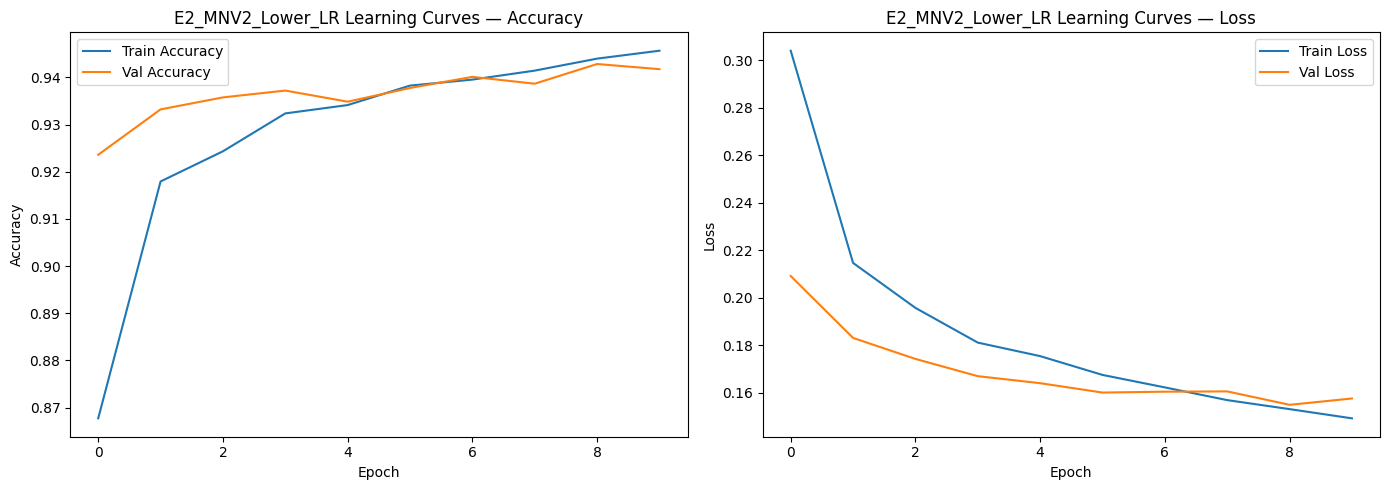

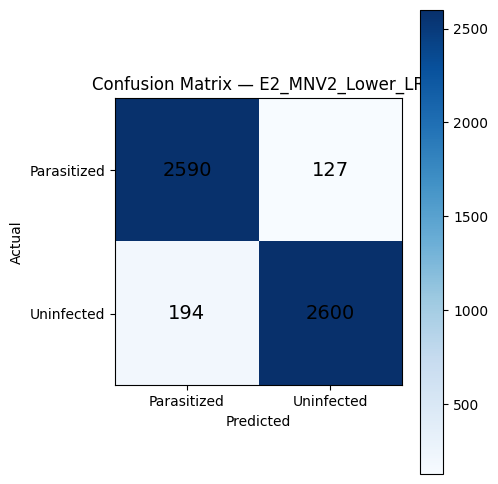

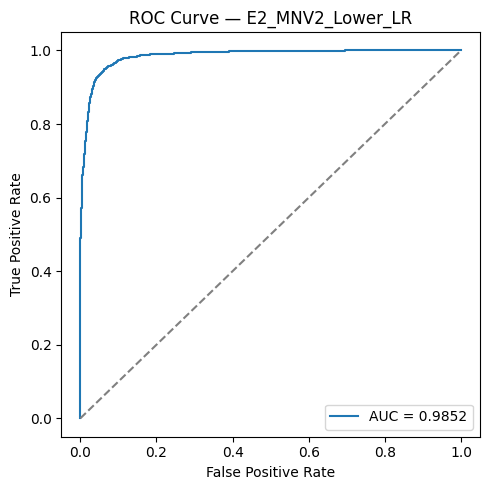

AUC: 0.9852

[Training] E3_MNV2_SGD_Opt  —  {'dense_units': 256, 'dropout_rate': 0.5, 'learning_rate': 0.001, 'optimizer_name': 'sgd'}
Epoch 1/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 31s 32ms/step - accuracy: 0.8601 - loss: 0.3188 - val_accuracy: 0.9133 - val_loss: 0.2193
Epoch 2/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.9062 - loss: 0.2379 - val_accuracy: 0.9209 - val_loss: 0.2039
Epoch 3/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.9169 - loss: 0.2156 - val_accuracy: 0.9238 - val_loss: 0.1944
Epoch 4/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.9207 - loss: 0.2040 - val_accuracy: 0.9303 - val_loss: 0.1824
Epoch 5/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.9247 - loss: 0.1967 - val_accuracy: 0.9330 - val_loss: 0.1757
Epoch 6/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.9287 - loss: 0.1884 - val_accuracy: 0.9325 - val_loss: 0.1740
Epoch 7/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.9301 - loss: 0.184

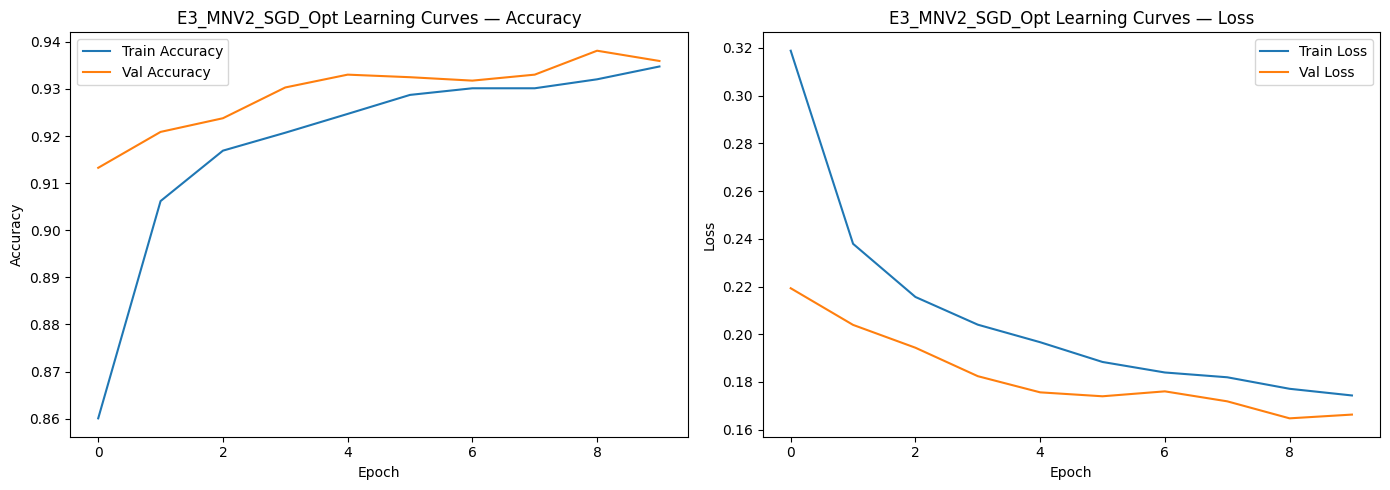

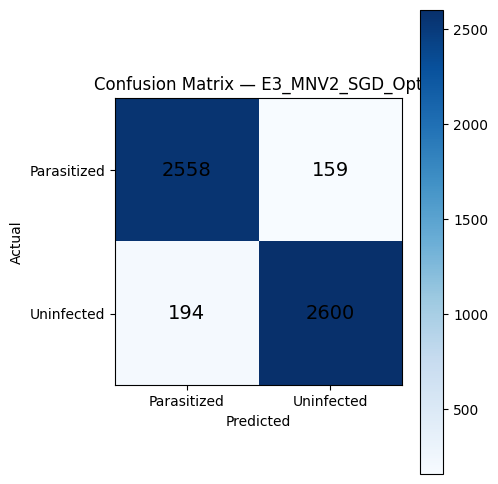

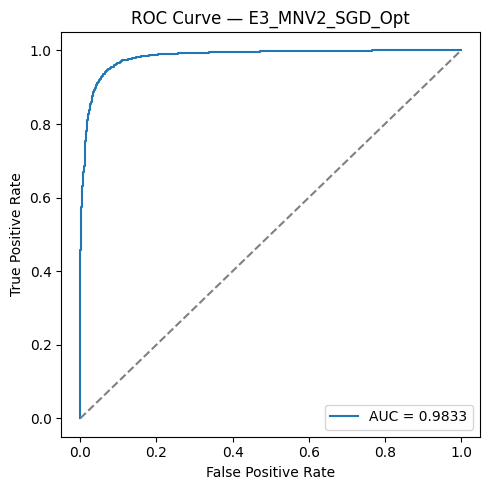

AUC: 0.9833

[Training] E4_MNV2_Dense64  —  {'dense_units': 64, 'dropout_rate': 0.5, 'learning_rate': 0.001, 'optimizer_name': 'adam'}
Epoch 1/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 32s 34ms/step - accuracy: 0.8922 - loss: 0.2706 - val_accuracy: 0.9276 - val_loss: 0.1816
Epoch 2/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - accuracy: 0.9213 - loss: 0.2076 - val_accuracy: 0.9332 - val_loss: 0.1738
Epoch 3/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.9272 - loss: 0.1950 - val_accuracy: 0.9340 - val_loss: 0.1668
Epoch 4/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.9283 - loss: 0.1867 - val_accuracy: 0.9356 - val_loss: 0.1662
Epoch 5/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.9322 - loss: 0.1810 - val_accuracy: 0.9398 - val_loss: 0.1553
Epoch 6/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.9361 - loss: 0.1732 - val_accuracy: 0.9394 - val_loss: 0.1584
Epoch 7/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.9351 - loss: 0.174

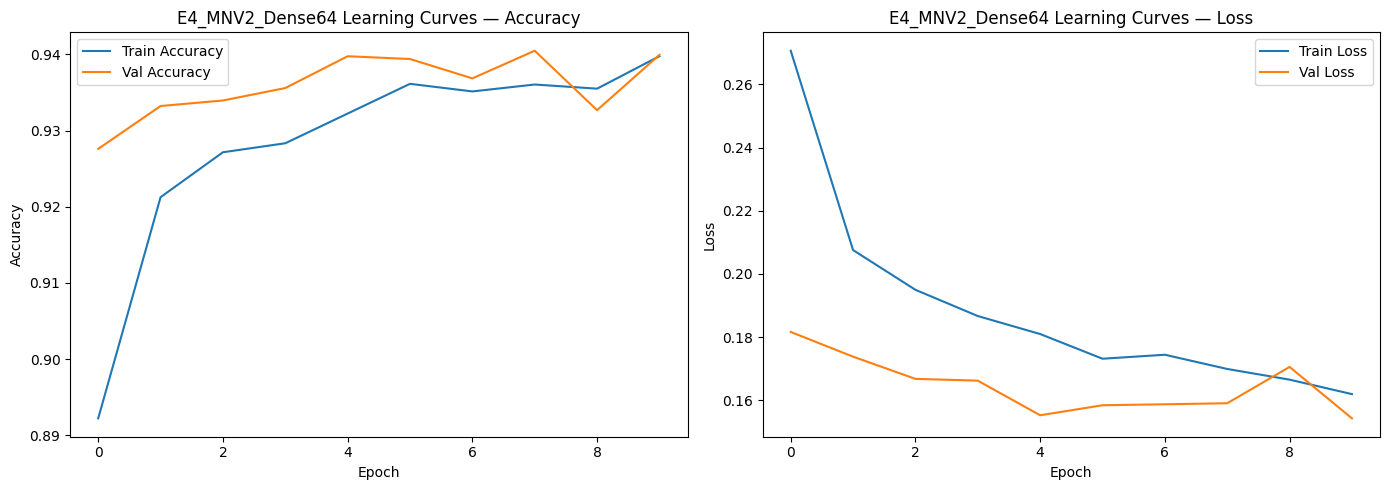

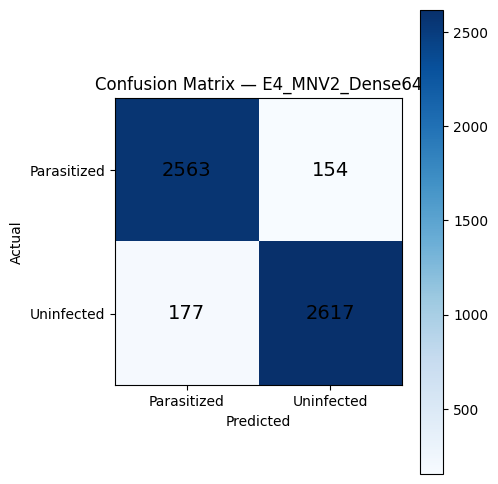

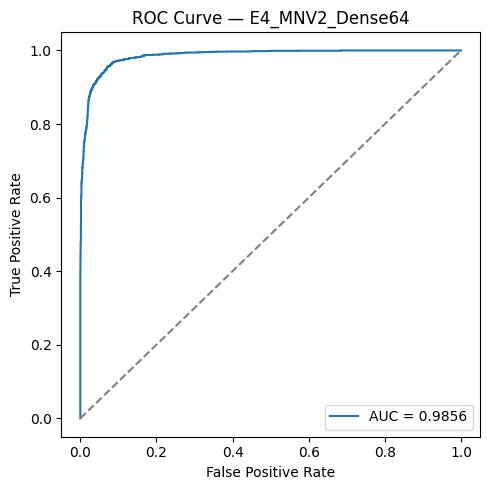

AUC: 0.9856

[Training] E5_MNV2_Dropout0.7  —  {'dense_units': 256, 'dropout_rate': 0.7, 'learning_rate': 0.001, 'optimizer_name': 'adam'}
Epoch 1/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 33s 34ms/step - accuracy: 0.8800 - loss: 0.2896 - val_accuracy: 0.9289 - val_loss: 0.1863
Epoch 2/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.9130 - loss: 0.2261 - val_accuracy: 0.9254 - val_loss: 0.1876
Epoch 3/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.9197 - loss: 0.2100 - val_accuracy: 0.9310 - val_loss: 0.1795
Epoch 4/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.9227 - loss: 0.2028 - val_accuracy: 0.9367 - val_loss: 0.1650
Epoch 5/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.9263 - loss: 0.1991 - val_accuracy: 0.9354 - val_loss: 0.1672
Epoch 6/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.9257 - loss: 0.1935 - val_accuracy: 0.9367 - val_loss: 0.1617
Epoch 7/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.9278 - loss: 

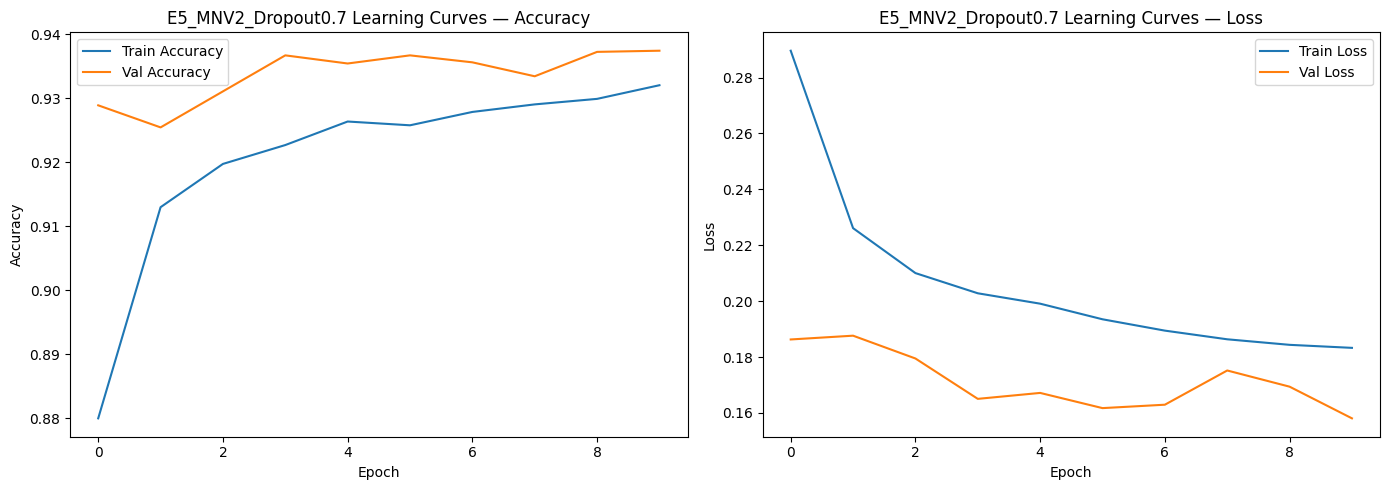

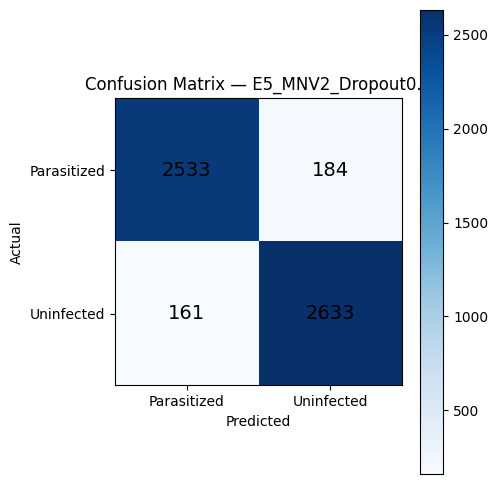

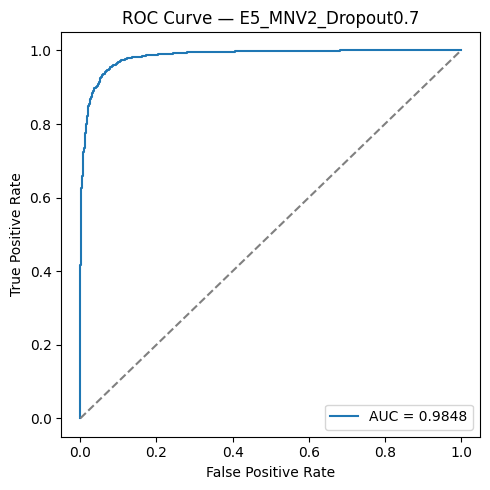

AUC: 0.9848

[Training] E6_MNV2_Augment  —  {'dense_units': 256, 'dropout_rate': 0.5, 'learning_rate': 0.001, 'optimizer_name': 'adam', 'use_augmentation': True}
Epoch 1/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 32s 32ms/step - accuracy: 0.8758 - loss: 0.3031 - val_accuracy: 0.9038 - val_loss: 0.2404
Epoch 2/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 35s 29ms/step - accuracy: 0.8979 - loss: 0.2574 - val_accuracy: 0.9111 - val_loss: 0.2325
Epoch 3/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.9021 - loss: 0.2451 - val_accuracy: 0.9165 - val_loss: 0.2350
Epoch 4/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.9039 - loss: 0.2436 - val_accuracy: 0.9203 - val_loss: 0.2061
Epoch 5/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 19s 28ms/step - accuracy: 0.9067 - loss: 0.2342 - val_accuracy: 0.9125 - val_loss: 0.2090
Epoch 6/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.9135 - loss: 0.2268 - val_accuracy: 0.9136 - val_loss: 0.2180
Epoch 7/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - ac

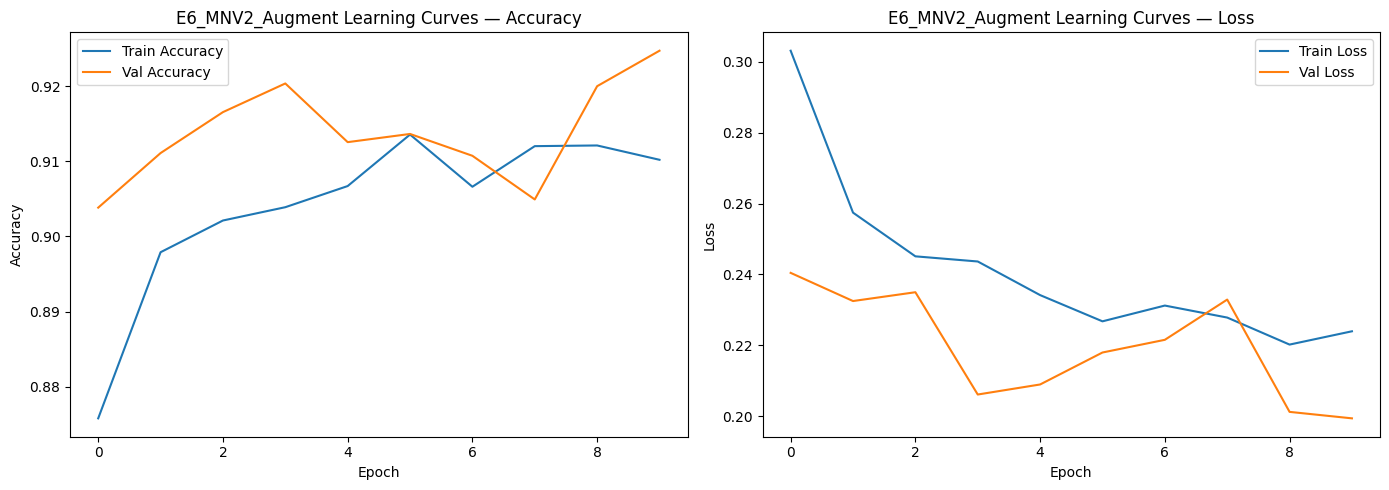

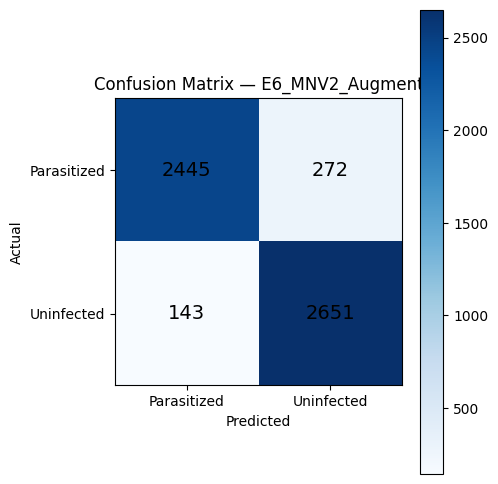

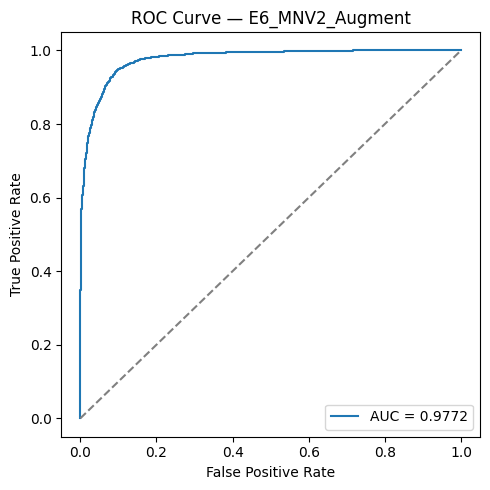

AUC: 0.9772

[Training] E7_MNV2_FineTune  —  {'dense_units': 256, 'dropout_rate': 0.5, 'learning_rate': 1e-05, 'optimizer_name': 'adam', 'fine_tune_layers': 20}
Epoch 1/10
687/689 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.8208 - loss: 0.3843

In [ ]:
mnv2_results = []        # rows for the summary table
all_mnv2_preds = {}      # name -> (y_true, y_pred, y_scores)
mnv2_histories = {}      # name -> history dict (for the record / re-plotting)

for name, cfg in EXPERIMENTS.items():
    print(f"\n{'='*70}\n[Training] {name}  —  {cfg}\n{'='*70}")
    model = build_mobilenetv2_model(**cfg)
    history = model.fit(train_ds, validation_data=val_ds, epochs=10, verbose=1)

    # Single predict pass over the whole validation set.
    y_true, y_pred, y_scores = evaluate_model(model, val_ds)

    mnv2_histories[name] = history.history
    all_mnv2_preds[name] = (y_true, y_pred, y_scores)
    mnv2_results.append([
        name,
        round(accuracy_score(y_true, y_pred), 4),
        round(precision_score(y_true, y_pred), 4),
        round(recall_score(y_true, y_pred), 4),
        round(f1_score(y_true, y_pred), 4),
    ])

    # Visualize now, while the predictions are fresh.
    plot_learning_curves(history, title=f"{name} Learning Curves")
    plot_confusion_matrix(y_true, y_pred, title=f"Confusion Matrix — {name}")
    plot_roc_curve(y_true, y_scores, title=f"ROC Curve — {name}")

    # Free the model before the next experiment.
    del model, history
    tf.keras.backend.clear_session()

print("\n[Status] All experiments complete!!!!")

## 8. Consolidated Performance Table

All seven experiments side by side (Accuracy / Precision / Recall / F1-Score), built from the
rows collected during the loop above.

In [ ]:
mnv2_results_df = pd.DataFrame(
    mnv2_results,
    columns=["Experiment", "Accuracy", "Precision", "Recall", "F1-Score"]
)

print("\n============= FINAL EXPERIMENTAL PERFORMANCE RESULTS =============")
display(mnv2_results_df.sort_values("F1-Score", ascending=False).reset_index(drop=True))